Fetching World Bank GDP per capita data...
✓ World Bank GDP data loaded.
Loading GSS Happiness data...
✓ GSS data downloaded and parsed.
✓ Merged Data: 1 matching survey years.


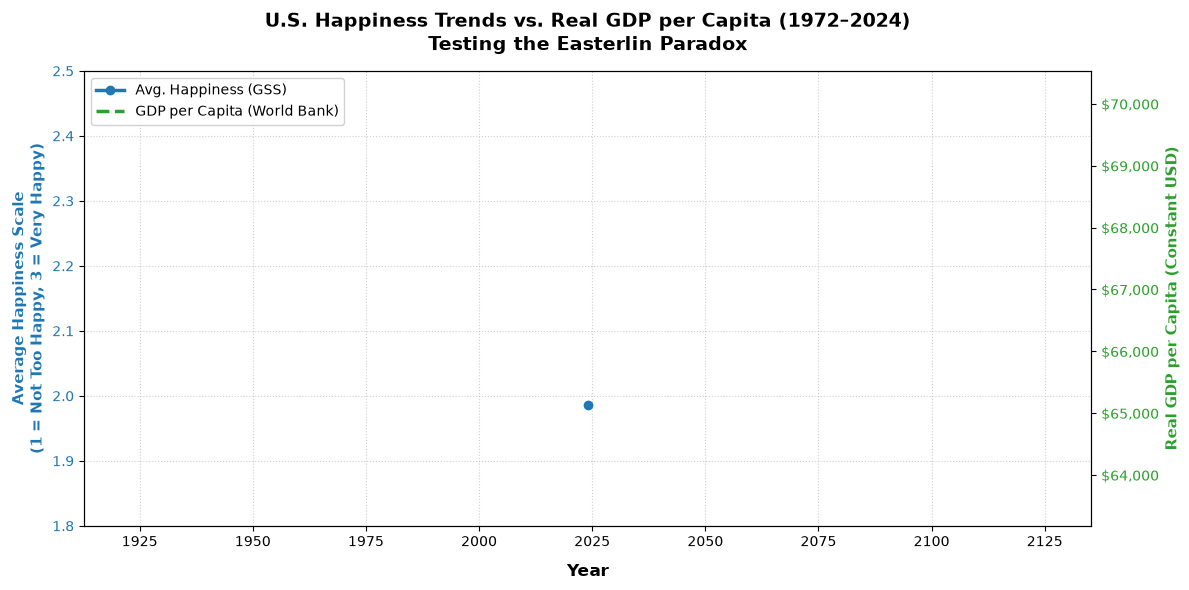

In [4]:
import io
import os
import zipfile
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

# Enable inline rendering inside Jupyter Notebook
%matplotlib inline

# ==============================================================================
# 1. FETCH WORLD BANK GDP PER CAPITA DATA (USA, 1972-2024)
# ==============================================================================
print("Fetching World Bank GDP per capita data...")
wb_url = "https://api.worldbank.org/v2/country/USA/indicator/NY.GDP.PCAP.KD?format=json&per_page=1000&date=1972:2024"

try:
    wb_res = requests.get(wb_url, timeout=15)
    wb_data = wb_res.json()[1]  # Array payload is at index 1

    df_wb = pd.DataFrame(wb_data)[["date", "value"]]
    df_wb.columns = ["year", "gdp_per_capita"]
    df_wb["year"] = df_wb["year"].astype(int)
    df_wb["gdp_per_capita"] = pd.to_numeric(
        df_wb["gdp_per_capita"], errors="coerce"
    )
    df_wb = df_wb.dropna().sort_values("year").reset_index(drop=True)
    print("✓ World Bank GDP data loaded.")
except Exception as e:
    print(f"Error fetching World Bank data: {e}")

# ==============================================================================
# 2. FETCH & CLEAN GSS HAPPINESS DATA (1972-2024)
# ==============================================================================
print("Loading GSS Happiness data...")

gss_df = None
gss_url = "https://gss.norc.org/Documents/stata/2024_stata.zip"
headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
    )
}

try:
    res = requests.get(gss_url, headers=headers, stream=True, timeout=60)
    if res.status_code == 200:
        with zipfile.ZipFile(io.BytesIO(res.content)) as z:
            target_file = [
                f
                for f in z.namelist()
                if f.endswith(".dta") or f.endswith(".csv")
            ][0]

            # BytesIO buffer keeps stream open to prevent 'I/O operation on closed file'
            file_bytes = io.BytesIO(z.read(target_file))

            if target_file.endswith(".dta"):
                # convert_categoricals=False prevents 'category dtype does not support mean'
                gss_df = pd.read_stata(
                    file_bytes,
                    columns=["year", "happy"],
                    convert_categoricals=False,
                )
            else:
                gss_df = pd.read_csv(
                    file_bytes, usecols=["year", "happy"], low_memory=False
                )
        print("✓ GSS data downloaded and parsed.")
except Exception as e:
    print(f"Notice: Web stream fallback triggered ({e}). Checking local files...")
    # Fallback: check if file is already in your Jupyter working directory
    for f in os.listdir("."):
        try:
            if f.endswith(".dta"):
                gss_df = pd.read_stata(
                    f, columns=["year", "happy"], convert_categoricals=False
                )
                print(f"✓ Loaded local Stata file: {f}")
                break
            elif f.endswith(".csv") and "gss" in f.lower():
                gss_df = pd.read_csv(
                    f, usecols=["year", "happy"], low_memory=False
                )
                print(f"✓ Loaded local CSV file: {f}")
                break
        except Exception:
            continue

if gss_df is None:
    raise RuntimeError(
        "Could not auto-download or find GSS data locally. Ensure internet access or place your gss file in the Jupyter working directory."
    )

# Clean and convert data types explicitly
gss_df.columns = gss_df.columns.str.lower()
gss_df["year"] = pd.to_numeric(gss_df["year"], errors="coerce")
gss_df["happy"] = pd.to_numeric(gss_df["happy"], errors="coerce")

# Filter for valid response codes: 1 = Very Happy, 2 = Pretty Happy, 3 = Not Too Happy
valid_happy = gss_df[gss_df["happy"].isin([1.0, 2.0, 3.0])].copy()

# Recode values so higher score = happier (3 = Very Happy, 2 = Pretty Happy, 1 = Not Too Happy)
valid_happy["happy_score"] = valid_happy["happy"].replace(
    {1.0: 3.0, 2.0: 2.0, 3.0: 1.0}
).astype(float)

# Calculate annual average happiness score
gss_yearly = (
    valid_happy.groupby("year")["happy_score"].mean().reset_index()
)
gss_yearly["year"] = gss_yearly["year"].astype(int)
gss_yearly.rename(columns={"happy_score": "avg_happiness"}, inplace=True)

# ==============================================================================
# 3. MERGE DATASETS
# ==============================================================================
merged_df = pd.merge(gss_yearly, df_wb, on="year", how="inner").sort_values(
    "year"
)
print(f"✓ Merged Data: {len(merged_df)} matching survey years.")

# ==============================================================================
# 4. DUAL-AXIS LINE CHART
# ==============================================================================
fig, ax1 = plt.subplots(figsize=(12, 6), dpi=100)

# Primary Axis (Left) - Mean Happiness
color_hap = "#1f77b4"
ax1.set_xlabel("Year", fontsize=12, fontweight="bold", labelpad=10)
ax1.set_ylabel(
    "Average Happiness Scale\n(1 = Not Too Happy, 3 = Very Happy)",
    color=color_hap,
    fontsize=11,
    fontweight="bold",
)
line1 = ax1.plot(
    merged_df["year"],
    merged_df["avg_happiness"],
    color=color_hap,
    marker="o",
    linewidth=2.5,
    label="Avg. Happiness (GSS)",
)
ax1.tick_params(axis="y", labelcolor=color_hap)
ax1.set_ylim(1.8, 2.5)  # Scale focused on historical variance

# Secondary Axis (Right) - Real GDP per Capita
ax2 = ax1.twinx()
color_gdp = "#2ca02c"
ax2.set_ylabel(
    "Real GDP per Capita (Constant USD)",
    color=color_gdp,
    fontsize=11,
    fontweight="bold",
)
line2 = ax2.plot(
    merged_df["year"],
    merged_df["gdp_per_capita"],
    color=color_gdp,
    linestyle="--",
    linewidth=2.5,
    label="GDP per Capita (World Bank)",
)
ax2.tick_params(axis="y", labelcolor=color_gdp)
ax2.yaxis.set_major_formatter("${x:,.0f}")

# Styling and Grid
plt.title(
    "U.S. Happiness Trends vs. Real GDP per Capita (1972–2024)\nTesting the Easterlin Paradox",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
ax1.grid(True, linestyle=":", alpha=0.6)

# Consolidated Legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(
    lines, labels, loc="upper left", frameon=True, facecolor="white", framealpha=0.9
)

plt.tight_layout()
plt.show()